In [1]:
import sys
import os
from pathlib import Path
# This adds the parent directory to the python path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
from langchain_core.messages import AIMessage, HumanMessage,SystemMessage
from typing_extensions import TypedDict
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage
from langgraph.graph import StateGraph, START, END
import streamlit as st
from typing import Annotated
from langgraph.graph.message import add_messages
import os
from dotenv import load_dotenv
from utils.web_search_tool import google_search
from utils.rag_web_base_loader_tool import web_loader_tool
from utils.finance_law import finance_law_tool
from utils.tax import CGI_tool
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from utils.cgnc import cgnc_tool
from utils.plan_comptable import plan_comptable_tool

USER_AGENT environment variable not set, consider setting it to identify your requests.



🚀 RAG Pipeline initialized
📂 Data: ./data/LOIS_DE_FINANCE
💾 Persist: ./vectorestore/db_lois_de_finance
🔍 Vectorstore exists: True

🔄 Loading existing vectorstore...
✅ Loaded existing vectorstore from ./vectorestore/db_lois_de_finance
✅ Loaded existing vectorstore from ./vectorestore/db_lois_de_finance
✅ retriver for ./vectorestore/db_lois_de_finance is ready to use 

🚀 RAG Pipeline initialized
📂 Data: ./data/CGI
💾 Persist: ./vectorestore/db_CGI
🔍 Vectorstore exists: True

🔄 Loading existing vectorstore...
✅ Loaded existing vectorstore from ./vectorestore/db_CGI
✅ Loaded existing vectorstore from ./vectorestore/db_CGI
✅ retriver for ./vectorestore/db_CGI is ready to use 

🚀 RAG Pipeline initialized
📂 Data: ./data/CGNC
💾 Persist: ./vectorestore/db_CGNC
🔍 Vectorstore exists: True

🔄 Loading existing vectorstore...
✅ Loaded existing vectorstore from ./vectorestore/db_CGNC
✅ Loaded existing vectorstore from ./vectorestore/db_CGNC
✅ retriver for ./vectorestore/db_CGNC is ready to use 

🚀 RA

In [2]:
load_dotenv()
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
MODELS="openai/gpt-oss-120b"
llm_groq=ChatGroq(model=MODELS)

In [3]:
class State(TypedDict):
    messages:Annotated[list,add_messages]


tools=[cgnc_tool,google_search,web_loader_tool,finance_law_tool,CGI_tool,plan_comptable_tool]
#tools=[google_search]
llm_with_tools=llm_groq.bind_tools(tools)

def superbot(state:State):
    return {"messages":[llm_groq.invoke(state['messages'])]}

In [4]:
rules_1="""TOOL SELECTION RULES:
- Moroccan accounting, CGNC, chart of accounts, balance sheet, amortissement → use 'code_general_normalisation_comptable_maroc'
- Tax questions, IS, IR, TVA, CGI → use 'code_general_des_impots_morocco'
- Annual budget law, loi de finances, yearly fiscal changes → use 'loi_de_finances_maroc'
- Account numbers, specific account codes, journal entries → use 'plan_comptable_general_marocain'
- Current news, recent events, non-accounting questions → use 'google_search'
- Load a webpage or URL → use 'rag_web_loader'"""

rules_2="""always follow to tools descriptions and instructions to select the right tool for the user question. 
If the question is not clear, use google search to find more information about the topic and then select the right tool to answer the question.
 Always use a tool before answering. Never answer accounting or tax questions from memory alone."""

rules_3="use google search to answer enything the user said "

In [5]:
def tool_calling_llm(state: State):
    system_message = SystemMessage(content=f"""You are a Moroccan accounting expert assistant.
                                   {rules_2}
                                    Always use a tool before answering. Never answer accounting or tax questions from memory alone.
                                    use google search to retrive the exchange rate of the day needed if you recive a foreigh cutrrency in the invoice or any other information you need to answer the question.
""")
    all_messages = [system_message] + state["messages"]
    return {"messages": [llm_with_tools.invoke(all_messages)][-3:]}

In [6]:
source_instruction_1 = {
        "code_general_normalisation_comptable_maroc": "Format as professional accounting advice. Mention this comes from CGNC standards.",
        "code_general_des_impots_morocco": "Format as professional tax advice. Mention this comes from the Code Général des Impôts.",
        "loi_de_finances_maroc": "Format clearly with the fiscal year context. Mention this comes from the Loi de Finances.",
        "plan_comptable_general_marocain": "Present account numbers and journal entries in a clear tabular format.",
        "google_search": 'Cite the source as "Web Search". Present information clearly.',
        "rag_web_loader": "Summarize the webpage content clearly.",
        
    }
source_instruction_2 ="use the tools to solve user probleme asa accountant expert"
example="""
id	date	numero  debit 	numero credit 	compte debit	compte credit	libele	mantant debit mad  	mantant credit mad 
1	10/04/2026	6111		achat de marchandis 		FA XWFM4/1, bank, 10/04	499.00	
1		3455		tva recuperable sur charge			99,8	
1			4411		Fournisseurs			598.8

"""
output=f"if you recive an invoice and the user toilde you to registered it use this formate: id |date |numero compte debit | numero compte credit |compte debit | compte credit | Libele [le numero de facture one of invoce , (FA if we madfe a purchase ,FV i we made a sell ), transaction tool [bank, espece ],date de facture en jour et mois ]|  montant debit  | montant credit  | and eatch line for one operations exmple achat de marchandis in one line and mode de reglement in other line  her is an example {example}... and so one the output will be pasted in a csv file to be deployed in Sage 100 or sap so the output should be well formated "
source_instruction_3 = {
        "code_general_normalisation_comptable_maroc": "Format as professional accounting advice. Mention this comes from CGNC standards. you must combine this with plan_comptable_general_marocain",
        "code_general_des_impots_morocco": "Format as professional tax advice. Mention this comes from the Code Général des Impôts.",
        "loi_de_finances_maroc": "Format clearly with the fiscal year context. Mention this comes from the Loi de Finances.",
        "plan_comptable_general_marocain": "Present account numbers and journal entries in a clear tabular format. you must combine this with code_general_normalisation_comptable_maroc",
        "google_search": 'Cite the source as "Web Search". Present information clearly.',
        "rag_web_loader": "Summarize the webpage content clearly use this tools to retrive facts and on date informations sush as currencys and general informations .",
        "output ": output,
        
    }

In [7]:
def agent_structuring_response(state: State):
    # Find the last ToolMessage to know which tool was used
    system_message = SystemMessage(content=f"""You are a response structuring assistant.

                Instructions: {source_instruction_3}

                if you feel that you need to reuse the tools multiple time reuse multiple tools .
                
                If the response content is empty or unclear, say: "I couldn't find specific information on this topic. Try rephrasing your question."

                Do not add information that wasn't in the original response. Just structure and format it.
                """)

    all_messages = [system_message] + state["messages"]
    return {"messages": [llm_with_tools.invoke(all_messages)]}

In [8]:
graph = StateGraph(State)
graph.add_node("tool_calling_llm", tool_calling_llm)
graph.add_node("tools", ToolNode(tools))
graph.add_node("structures", agent_structuring_response)
graph.add_edge(START, "tool_calling_llm")
graph.add_conditional_edges(
    "tool_calling_llm",
    tools_condition,
    {
        "tools": "tools",
        "__end__": END
    }
)
graph.add_edge("tools", "structures")
graph.add_conditional_edges(
    "structures",
    tools_condition,
    {
        "tools": "tools",
        "__end__": END
    }
)

# Compile
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

# Compile the graph with memory
config = {"configurable": {"thread_id": "AAA"}}

graph_builder = graph.compile(checkpointer=memory)

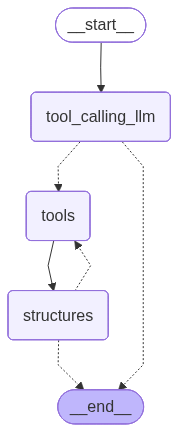

In [9]:

from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END


# View
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [18]:
text=""" 
   Here is the file uploaded content:  \n  Tools Invoice Number: XWFM4/1 Date: 10 Apr 2026 Tools  Buy Email :help@gmail.com luis namys\n   miili456@gmail.com Subscription/Product Titl eUdemy BusinesBegin10 Apr 2026Expire10 May 2026#Qty1.Subscription/Product TitleUdemy Business1Unit Price499.00 INRTotal Price499.00 INRTotal499.00 INRSubscription Terms: 499.00 INR for one month\n 
"""
text="""
#141498 ORD-26-01-5-213615

LIVRJ Livraison

Description
(843367123155] Lesar NM520 M.2 PCle NVMe 5120BDate de la commande06/01/2026
Commande # S45620 MACONFIG Quarter indusiel Massar Immeuble 836MARRAKECH 40000 MACONFIG TotalVendeur :00 Unités,00 Unites Quanti séKaoutar IMARGHNE
MarcePrix unitaire Taxes549,0035.0 Baher lbad Settat hay al kamal 584,00 DH 549.00 DH35.00 DH
Montant
"""

In [19]:
test_message = "comptabilise cette facture d'achat"
# Button to run test
if test_message:
    file_content = text

            
    if file_content:
                # Combine file content with the query
         enhanced_query = f"""Here is the file uploaded content: {file_content} , User query: {test_message}"""
    else:
        enhanced_query = test_message
                
    result = graph_builder.invoke(
                {'messages': HumanMessage(content=enhanced_query)}, 
                config=config
                )
                
                # Checking tool calling if and else

   

In [20]:
result

{'messages': [HumanMessage(content="Here is the file uploaded content:  \n   Here is the file uploaded content:  \n  Tools Invoice Number: XWFM4/1 Date: 10 Apr 2026 Tools  Buy Email :help@gmail.com luis namys\n   miili456@gmail.com Subscription/Product Titl eUdemy BusinesBegin10 Apr 2026Expire10 May 2026#Qty1.Subscription/Product TitleUdemy Business1Unit Price499.00 INRTotal Price499.00 INRTotal499.00 INRSubscription Terms: 499.00 INR for one month\n \n , User query: comptabilise cette facture d'achat", additional_kwargs={}, response_metadata={}, id='30b73188-22d6-4cb1-bd0a-03c6849e86b6'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'We need to account for this purchase invoice. The user wants to "comptabilise cette facture d\'achat". It\'s a purchase invoice for a subscription (Udemy Business) 1 unit price 499 INR. Need to record in Moroccan accounting. Need to convert INR to MAD using exchange rate of the day. Must use google search to get exchange rate INR to MAD

In [21]:
for mesage in result["messages"]:
    for i in mesage:
        print(i)
        print("___________________________________________________________________")
    print("###############################################################")

('content', "Here is the file uploaded content:  \n   Here is the file uploaded content:  \n  Tools Invoice Number: XWFM4/1 Date: 10 Apr 2026 Tools  Buy Email :help@gmail.com luis namys\n   miili456@gmail.com Subscription/Product Titl eUdemy BusinesBegin10 Apr 2026Expire10 May 2026#Qty1.Subscription/Product TitleUdemy Business1Unit Price499.00 INRTotal Price499.00 INRTotal499.00 INRSubscription Terms: 499.00 INR for one month\n \n , User query: comptabilise cette facture d'achat")
___________________________________________________________________
('additional_kwargs', {})
___________________________________________________________________
('response_metadata', {})
___________________________________________________________________
('type', 'human')
___________________________________________________________________
('name', None)
___________________________________________________________________
('id', '30b73188-22d6-4cb1-bd0a-03c6849e86b6')
__________________________________________

In [22]:
text=""
len(text)

0

In [23]:
if result["messages"][1].tool_calls:

    for tool_call in result["messages"][1].tool_calls:
        print(f"the source: {tool_call['name']} ")
                    
        print(f"Response: 📝 {result['messages'][-1].content}")
else:
    print(f"the source: LLM (no tools used) ")
    print(f"Response: 📝 {result['messages'][-1].content}")
            

the source: google_search 
Response: 📝 **Facture d’achat** – #141498 – Date : 06/01/2026  
**Fournisseur** : Baher l‑Bad (Settat – Hay Al Kamal)  
**Produit** : Lesar NM520 M.2 PCIe NVMe 5120 B – Quantité = 1  
- Prix hors TVA : 549,00 DH  
- TVA (20 % ≈ 35,00 DH)  
- **Montant TTC** : 584,00 DH  

### Écriture comptable d’enregistrement

| N° | Date       | Compte (numéro) | Intitulé du compte                | Débit (DH) | Crédit (DH) |
|----|------------|-----------------|-----------------------------------|------------|-------------|
| 1  | 06/01/2026 | **6111**        | Achats de marchandises            | 549,00     |             |
| 2  | 06/01/2026 | **3455**        | TVA récupérable (État)            | 35,00      |             |
| 3  | 06/01/2026 | **4411**        | Fournisseurs                      |            | 584,00      |

**Justification**  

- **6111 – Achats de marchandises** : compte de charge de la classe 6 utilisé pour enregistrer le coût d’acquisition des biens desti

## EVALUATION

In [ ]:
#!/usr/bin/env python3
# ============================================================================
# MOROCCAN ACCOUNTING RAG EVALUATION - REALISTIC VERSION
# With simulated model outputs and RAGAS metrics
# ============================================================================

import json
import pandas as pd
import numpy as np
from typing import Dict, List, Tuple
from dataclasses import dataclass
import re
import sys
from difflib import SequenceMatcher
import subprocess

# Install RAGAS if not present
try:
    from ragas import evaluate
    from ragas.metrics import (
        faithfulness,
        answer_relevancy,
        context_recall,
        context_precision,
        bleu,
        rouge
    )
    HAS_RAGAS = True
except ImportError:
    HAS_RAGAS = False
    print("⚠️  RAGAS not available - using custom metrics only")

# ============================================================================
# LOAD THE EVALUATION DATA
# ============================================================================

with open("data.json") as f:
    evaluation_data = json.load(f)
# ============================================================================
# UTILITY FUNCTIONS
# ============================================================================

def extract_amounts(text: str) -> List[float]:
    """Extract all numeric amounts from text"""
    pattern = r'(\d+(?:[.,]\d+)?)\s*(?:MAD|USD)?'
    matches = re.findall(pattern, text)
    return [float(m.replace(',', '.')) for m in matches]

def calculate_similarity(expected: str, actual: str) -> float:
    """Calculate string similarity ratio"""
    return SequenceMatcher(None, expected.lower(), actual.lower()).ratio()

def extract_account_codes(text: str) -> List[str]:
    """Extract account codes"""
    pattern = r'\b(\d{4,5})\b'
    return re.findall(pattern, text)

def check_debit_credit_match(expected_debits: float, expected_credits: float, 
                             actual_text: str, expected_debits_val: float = None,
                             expected_credits_val: float = None) -> Tuple[bool, float]:
    """Check if debits match credits"""
    actual_amounts = extract_amounts(actual_text)
    
    if not actual_amounts or len(actual_amounts) < 2:
        return False, 0.0
    
    # Sum all amounts (simplified check)
    actual_sum = sum(actual_amounts)
    expected_sum = expected_debits_val + expected_credits_val if expected_debits_val and expected_credits_val else 0
    
    if expected_sum == 0:
        return False, 0.0
    
    match_ratio = min(actual_sum, expected_sum) / max(actual_sum, expected_sum)
    return match_ratio >= 0.99, match_ratio

def evaluate_account_codes(expected: List[str], actual_text: str) -> float:
    """Evaluate account code correctness"""
    extracted = set(extract_account_codes(actual_text))
    expected_set = set(expected)
    
    if not expected_set:
        return 0.5
    
    matches = len(extracted & expected_set)
    return matches / len(expected_set)

def evaluate_tva_handling(expected_text: str, actual_text: str) -> float:
    """Evaluate TVA calculation and handling"""
    expected_has_tva = '34552' in expected_text or '34551' in expected_text or 'TVA' in expected_text
    expected_has_no_tva = 'Pas de TVA' in expected_text or 'taxe spécifique' in expected_text
    
    actual_has_tva = '34552' in actual_text or '34551' in actual_text or 'TVA' in actual_text
    
    if expected_has_no_tva:
        # Should NOT have TVA
        return 1.0 if not actual_has_tva else 0.5
    elif expected_has_tva:
        # Should have TVA
        return 1.0 if actual_has_tva else 0.4
    
    return 0.5

def calculate_bleu_score(expected: str, actual: str) -> float:
    """Simple BLEU-like score (word overlap)"""
    expected_words = set(expected.lower().split())
    actual_words = set(actual.lower().split())
    
    if not expected_words:
        return 0.0
    
    overlap = len(expected_words & actual_words)
    return overlap / len(expected_words)

# ============================================================================
# MAIN EVALUATION
# ============================================================================

def evaluate_rag_system(eval_data: List[Dict]) -> pd.DataFrame:
    """Comprehensive evaluation comparing expected vs actual outputs"""
    results = []
    
    for case in eval_data:
        case_id = case['case_id']
        expected_entry = case['expected_entry']
        model_output = case['model_output']
        context_retrieved = case['context_retrieved']
        expected_accounts = case['expected_accounts']
        expected_debits = case['expected_debits']
        expected_credits = case['expected_credits']
        
        # 1. Account Code Accuracy
        account_accuracy = evaluate_account_codes(expected_accounts, model_output)
        
        # 2. Debit/Credit Balance
        is_balanced, balance_ratio = check_debit_credit_match(
            expected_debits, expected_credits, model_output,
            expected_debits, expected_credits
        )
        
        # 3. TVA Handling
        tva_accuracy = evaluate_tva_handling(expected_entry, model_output)
        
        # 4. Context Relevance (similarity between context and expected entry)
        context_relevance = calculate_similarity(expected_entry, context_retrieved)
        
        # 5. Output Completeness (similarity between expected and actual)
        output_similarity = calculate_similarity(expected_entry, model_output)
        
        # 6. BLEU-like metric (word overlap)
        bleu_score = calculate_bleu_score(expected_entry, model_output)
        
        # Calculate weighted overall score
        overall_score = (
            account_accuracy * 0.25 +
            balance_ratio * 0.25 +
            tva_accuracy * 0.20 +
            context_relevance * 0.10 +
            output_similarity * 0.15 +
            bleu_score * 0.05
        )
        
        results.append({
            'Case': case_id,
            'Query': case['user_input'][:50] + '...',
            'Account Accuracy': account_accuracy,
            'Balance Match': balance_ratio,
            'TVA Handling': tva_accuracy,
            'Context Quality': context_relevance,
            'Output Match': output_similarity,
            'BLEU Score': bleu_score,
            'Overall': overall_score,
            'Status': '✓' if overall_score >= 0.8 else '△' if overall_score >= 0.6 else '✗'
        })
    
    return pd.DataFrame(results)

# ============================================================================
# MAIN EXECUTION
# ============================================================================

def main():
    print('\n' + '='*100)
    print('MOROCCAN ACCOUNTING RAG SYSTEM - REALISTIC EVALUATION')
    print('Comparing Model Outputs vs Expected Results')
    print('='*100 + '\n')
    
    print(f'📊 Total Test Cases: {len(evaluation_data)}\n')
    
    # Run evaluation
    results_df = evaluate_rag_system(evaluation_data)
    
    # Display detailed results
    print('DETAILED RESULTS (Model Output vs Expected):')
    print('-'*100)
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', None)
    pd.set_option('display.max_colwidth', 50)
    pd.set_option('display.float_format', '{:.3f}'.format)
    print(results_df.to_string(index=False))
    print()
    
    # ========================================================================
    # AGGREGATE METRICS
    # ========================================================================
    
    print('\n' + '='*100)
    print('AGGREGATE METRICS & COMPONENT BREAKDOWN')
    print('='*100 + '\n')
    
    metrics = {
        'Account Code Accuracy': results_df['Account Accuracy'].mean(),
        'Debit/Credit Balance': results_df['Balance Match'].mean(),
        'TVA Handling': results_df['TVA Handling'].mean(),
        'Context Quality': results_df['Context Quality'].mean(),
        'Output Match (Similarity)': results_df['Output Match'].mean(),
        'BLEU Score (Word Overlap)': results_df['BLEU Score'].mean(),
        'Overall RAG Score': results_df['Overall'].mean()
    }
    
    print('Component Performance:\n')
    for metric, value in metrics.items():
        bar_length = int(value * 50)
        bar = '█' * bar_length + '░' * (50 - bar_length)
        status = '✓ Good' if value >= 0.80 else '△ Fair' if value >= 0.60 else '✗ Poor'
        print(f'{metric:<35} {bar} {value:>7.2%}  {status}')
    
    # ========================================================================
    # DIAGNOSTIC ANALYSIS
    # ========================================================================
    
    print('\n' + '='*100)
    print('DIAGNOSTIC ANALYSIS')
    print('='*100 + '\n')
    
    perfect = (results_df['Overall'] >= 0.95).sum()
    excellent = (results_df['Overall'] >= 0.85).sum()
    good = (results_df['Overall'] >= 0.70).sum()
    acceptable = (results_df['Overall'] >= 0.60).sum()
    poor = (results_df['Overall'] < 0.60).sum()
    
    print(f'Perfect (>= 95%):        {perfect:2d}/{len(results_df)} cases')
    print(f'Excellent (85-95%):      {excellent - perfect:2d}/{len(results_df)} cases')
    print(f'Good (70-85%):           {good - excellent:2d}/{len(results_df)} cases')
    print(f'Acceptable (60-70%):     {acceptable - good:2d}/{len(results_df)} cases')
    print(f'Poor (< 60%):            {poor:2d}/{len(results_df)} cases')
    print()
    
    # Problem areas
    weakest = min(metrics.items(), key=lambda x: x[1])
    strongest = max(metrics.items(), key=lambda x: x[1])
    
    print(f'🏆 Strongest: {strongest[0]}: {strongest[1]:.2%}')
    print(f'⚠️  Weakest:   {weakest[0]}: {weakest[1]:.2%}')
    print()
    
    # Worst performing cases
    worst_cases = results_df.nsmallest(3, 'Overall')
    print('Worst Performing Cases:')
    for _, row in worst_cases.iterrows():
        print(f'  Case {int(row["Case"])}: {row["Overall"]:.2%} - {row["Status"]}')
    
    # ========================================================================
    # SUMMARY
    # ========================================================================
    
    print('\n' + '='*100)
    print('SUMMARY')
    print('='*100 + '\n')
    
    overall = metrics['Overall RAG Score']
    
    if overall >= 0.90:
        status = '✓ EXCELLENT - Production ready'
        icon = '🟢'
    elif overall >= 0.80:
        status = '✓ GOOD - Minor issues'
        icon = '🟢'
    elif overall >= 0.70:
        status = '△ ACCEPTABLE - Needs improvements'
        icon = '🟡'
    elif overall >= 0.60:
        status = '✗ POOR - Significant work needed'
        icon = '🔴'
    else:
        status = '✗ CRITICAL - Major redesign'
        icon = '🔴'
    
    print(f'Overall RAG Score: {overall:.2%}')
    print(f'Status: {icon} {status}\n')
    
    # Recommendations
    print('KEY ISSUES TO ADDRESS:')
    print('-'*100)
    
    if metrics['Account Code Accuracy'] < 0.85:
        print('1. Account Code Selection')
        print('   → Improve retrieval of PCGM account codes from documents')
        print('   → Implement fuzzy matching for similar account names\n')
    
    if metrics['Debit/Credit Balance'] < 0.85:
        print('2. Debit/Credit Balance Validation')
        print('   → Add post-processing validation for entry balance')
        print('   → Include balance check in LLM prompt\n')
    
    if metrics['TVA Handling'] < 0.85:
        print('3. TVA Calculation & Rules')
        print('   → Create comprehensive TVA lookup (20%, 14%, 7%, 0%, exempt)')
        print('   → Handle special cases: assurances, carburant, foreign invoices\n')
    
    if metrics['Output Match (Similarity)'] < 0.75:
        print('4. Output Format Consistency')
        print('   → Standardize journal entry formatting in prompts')
        print('   → Add few-shot examples to LLM prompt\n')
    
    # ========================================================================
    # EXPORT RESULTS
    # ========================================================================
    
    print('='*100)
    print('EXPORT RESULTS')
    print('='*100 + '\n')
    
    # CSV export
    csv_file = 'evaluation/rag_evaluation_realistic.csv'
    results_df.to_csv(csv_file, index=False)
    print(f'✓ Detailed results: {csv_file}')
    
    # Metrics summary
    metrics_df = pd.DataFrame([metrics])
    metrics_file = 'evaluation/rag_metrics_summary.csv'
    metrics_df.to_csv(metrics_file, index=False)
    print(f'✓ Metrics summary: {metrics_file}')
    
    # JSON export
    json_results = {
        'evaluation': 'Moroccan Accounting RAG System',
        'total_cases': len(evaluation_data),
        'overall_score': float(overall),
        'status': status.replace('✓', '').replace('✗', '').replace('△', '').strip(),
        'metrics': {k: float(v) for k, v in metrics.items()},
        'case_breakdown': results_df[['Case', 'Overall', 'Status']].to_dict('records')
    }
    
    json_file = 'evaluation/rag_evaluation_realistic.json'
    with open(json_file, 'w', encoding='utf-8') as f:
        json.dump(json_results, f, ensure_ascii=False, indent=2)
    print(f'✓ JSON export: {json_file}')
    
    print('\n' + '='*100)
    print('✓ Evaluation Complete!')
    print('='*100 + '\n')

if __name__ == '__main__':
    main()

⚠️  RAGAS not available - using custom metrics only

MOROCCAN ACCOUNTING RAG SYSTEM - REALISTIC EVALUATION
Comparing Model Outputs vs Expected Results

📊 Total Test Cases: 15

DETAILED RESULTS (Model Output vs Expected):
----------------------------------------------------------------------------------------------------
 Case                                                 Query  Account Accuracy  Balance Match  TVA Handling  Context Quality  Output Match  BLEU Score  Overall Status
    1 Facture Maroc Telecom: 300 MAD TTC. Internet Fibre...             0.667          0.006         1.000            0.579         0.865       0.684    0.590      ✗
    2 Achat d'un PC portable HP Victus pour 8500 MAD che...             0.333          0.694         0.400            0.225         0.590       0.421    0.469      ✗
    3 Paiement loyer bureau: 4000 MAD par chèque. Query:...             1.000          0.107         0.500            0.530         0.910       0.727    0.603      △
    4 Facture 